In [33]:
import math
import qiskit
import qiskit_aer
from qiskit import QuantumCircuit
from qiskit.circuit.library import ZZFeatureMap
from qiskit.circuit.library import EfficientSU2
from qiskit.circuit.library import TwoLocal 
from math import pi
import warnings
warnings.filterwarnings('ignore')

## **Basis encoding**

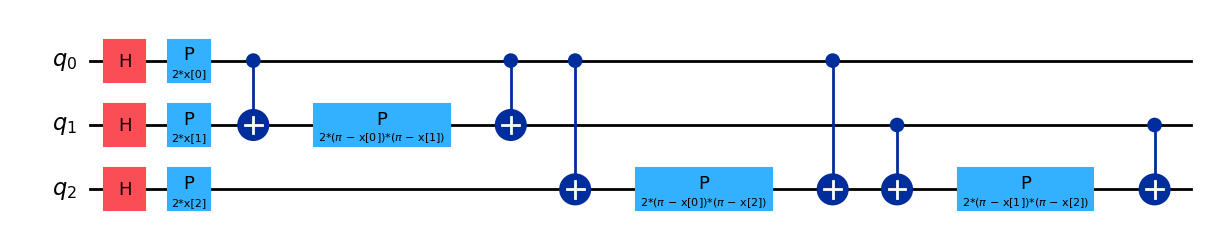

In [34]:
# 3 features, depth 1
map_zz = ZZFeatureMap(feature_dimension=3, reps=1)
map_zz.decompose().draw('mpl')

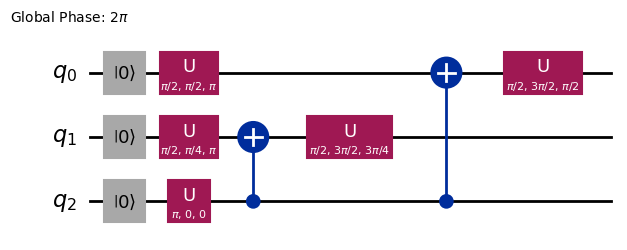

In [35]:
desired_state = [
    0,
    0,
    0,
    0,
    0,
    1 / math.sqrt(2),
    0,
    1 / math.sqrt(2)]

qc = QuantumCircuit(3)
qc.initialize(desired_state, [0,1,2])
qc.decompose().decompose().decompose().decompose().decompose().draw('mpl')

## **Amplitude encoding**

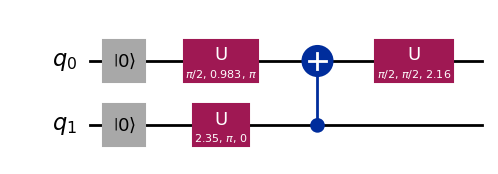

In [36]:
desired_state = [
    1 / math.sqrt(15.25) * 1.5,
    0,
    1 / math.sqrt(15.25) * -2,
    1 / math.sqrt(15.25) * 3]

qc = QuantumCircuit(2)
qc.initialize(desired_state, [0,1])

qc.decompose().decompose().decompose().decompose().decompose().draw('mpl')


## **Angle encoding**

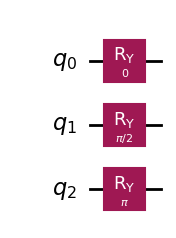

In [37]:
qc = QuantumCircuit(3)
qc.ry(0, 0)
qc.ry(2*math.pi/4, 1)
qc.ry(2*math.pi/2, 2)
qc.draw('mpl')



## **Arbitrary encoding**

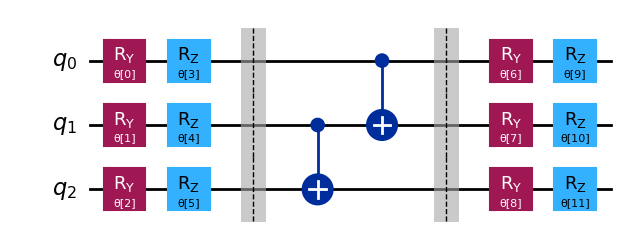

In [38]:
circuit = EfficientSU2(num_qubits=3, reps=1, insert_barriers=True)
circuit.decompose().draw('mpl')


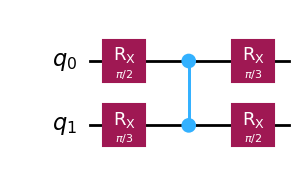

In [39]:
reference_circuit = TwoLocal(2, "rx", "cz", entanglement="linear", reps=1) 
theta_list = [pi / 2, pi / 3, pi / 3, pi / 2]

reference_circuit = reference_circuit.assign_parameters(theta_list)

reference_circuit.decompose().draw("mpl")

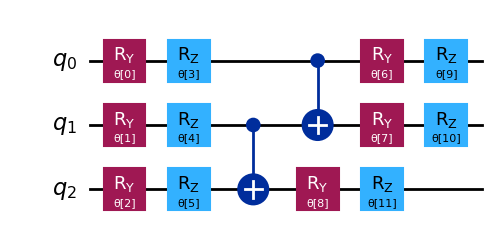

In [40]:
circuit = EfficientSU2(3, reps=1)
circuit.decompose().draw("mpl")

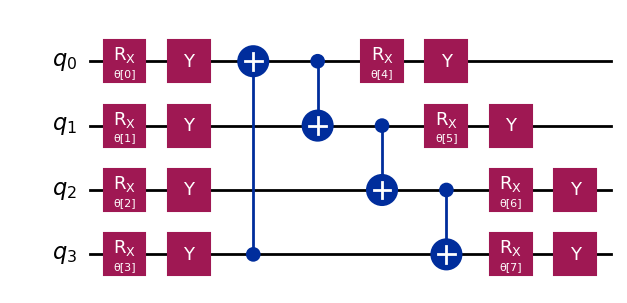

In [41]:
ansatz = EfficientSU2(4, su2_gates=['rx', 'y'], entanglement='circular', reps=1,flatten=True)
qc = QuantumCircuit(4) 
qc.compose(ansatz, inplace=True)
qc.draw('mpl')